# Business Value & Explainability

Hai phần mở rộng sau khi baseline đã vững:

- **Part A — Cost-based threshold**: thay F2-score (một con số trừu tượng) bằng hàm giá trị kỳ vọng tính bằng tiền, để chọn threshold theo lợi ích kinh doanh.
- **Part B — Explainable AI**: feature importance kiểu gain/split của tree model chỉ cho biết *mức độ* quan trọng, không cho biết *chiều* tác động. SHAP cho cả hai và giải thích được từng dự đoán cụ thể, áp dụng ngay vào 2 khách hàng đã nêu ở error analysis.

Dùng lại nguyên `final_pipeline` (CatBoost tuned), không train lại.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.model_selection import StratifiedKFold, cross_val_predict

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.churn_classification.data_split import RANDOM_STATE, get_split
from src.churn_classification.final_model import build_final_pipeline
from src.churn_classification.preprocessing import compute_scale_pos_weight, split_X_y

train_df, test_df = get_split()
X_train, y_train = split_X_y(train_df)
X_test, y_test = split_X_y(test_df)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scale_pos_weight_train = compute_scale_pos_weight(y_train)
final_pipeline = build_final_pipeline(scale_pos_weight=scale_pos_weight_train, random_state=RANDOM_STATE)
final_pipeline.fit(X_train, y_train)

# OOF probabilities tren train pool :
# chon threshold tren OOF, KHONG dung test set.
oof_pipeline = build_final_pipeline(scale_pos_weight=scale_pos_weight_train, random_state=RANDOM_STATE)
oof_proba = cross_val_predict(oof_pipeline, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
test_proba = final_pipeline.predict_proba(X_test)[:, 1]

print("Da fit final_pipeline va tinh OOF probabilities tren train pool.")


Loading cached split from /home/tthhieu/survival-analysis/data/processed/churn_classification (created earlier). Delete this folder and re-run to regenerate with current TEST_SIZE/RANDOM_STATE.


Da fit final_pipeline va tinh OOF probabilities tren train pool.


## Part A — Cost-based threshold

### A.1 Mô hình giá trị (value model)

Dataset công khai này không có số liệu chi phí/lợi ích thật từ business. Thay vì tiếp tục dùng F2 trừu tượng, ở đây xây một mô hình giá trị bằng tiền với giả định minh bạch và có thể chỉnh, rồi kiểm tra độ nhạy thay vì tin vào một con số duy nhất:

- `OFFER_COST = 50` (USD): chi phí trung bình một ưu đãi giữ chân.
- `RETAINED_MONTHS = 12`: số tháng doanh thu giữ được nếu ưu đãi thành công.
- `RETENTION_SUCCESS_RATE = 0.30`: xác suất một khách sắp rời đi đồng ý ở lại nhờ ưu đãi (con số điển hình cho retention campaign, không phải số liệu thật của bộ dữ liệu này; sẽ kiểm tra độ nhạy ở A.3).
- `MonthlyCharges` của từng khách làm proxy cho doanh thu hàng tháng, nên khách trả phí cao có giá trị kỳ vọng cao hơn khi giữ được, sát thực tế hơn một tỷ lệ FN/FP cố định cho mọi khách.

Giá trị kỳ vọng theo từng outcome (so với baseline "không làm gì"):

| Outcome | Giá trị kỳ vọng |
|---|---|
| Gắn cờ + thực sự churn (TP) | `RETENTION_SUCCESS_RATE * RETAINED_MONTHS * MonthlyCharges - OFFER_COST` |
| Gắn cờ + thực ra không churn (FP) | `-OFFER_COST` (lãng phí ưu đãi) |
| Không gắn cờ (FN hoặc TN) | `0` (không hành động) |

In [2]:
OFFER_COST = 50.0
RETAINED_MONTHS = 12.0
RETENTION_SUCCESS_RATE = 0.30


def expected_value_at_threshold(
    proba: np.ndarray,
    y_true: np.ndarray,
    monthly_charges: np.ndarray,
    threshold: float,
    offer_cost: float = OFFER_COST,
    retained_months: float = RETAINED_MONTHS,
    success_rate: float = RETENTION_SUCCESS_RATE,
) -> float:
    flagged = proba >= threshold
    tp_mask = flagged & (y_true == 1)
    fp_mask = flagged & (y_true == 0)
    tp_value = (success_rate * retained_months * monthly_charges[tp_mask] - offer_cost).sum()
    fp_value = -offer_cost * fp_mask.sum()
    return tp_value + fp_value


### A.2 Quét threshold trên OOF (train pool), không đụng test set — đúng nguyên tắc đã chốt ở Pha 4


In [3]:
monthly_charges_train = train_df["MonthlyCharges"].to_numpy()
y_train_arr = y_train.to_numpy()

thresholds = np.linspace(0.01, 0.99, 197)
expected_values = np.array(
    [
        expected_value_at_threshold(oof_proba, y_train_arr, monthly_charges_train, t)
        for t in thresholds
    ]
)
best_idx = int(np.argmax(expected_values))
cost_based_threshold = thresholds[best_idx]

f2_threshold = 0.295  # tu Pha 4
value_at_f2_threshold = expected_value_at_threshold(oof_proba, y_train_arr, monthly_charges_train, f2_threshold)
value_at_default = expected_value_at_threshold(oof_proba, y_train_arr, monthly_charges_train, 0.5)

print(f"Threshold toi uu theo gia tri ky vong (OOF): {cost_based_threshold:.3f}")
print(f"  Gia tri ky vong tai threshold nay      : ${expected_values[best_idx]:,.0f}")
print(f"Gia tri ky vong tai threshold F2 (0.295)  : ${value_at_f2_threshold:,.0f}")
print(f"Gia tri ky vong tai threshold mac dinh 0.5: ${value_at_default:,.0f}")


Threshold toi uu theo gia tri ky vong (OOF): 0.465
  Gia tri ky vong tai threshold nay      : $232,017
Gia tri ky vong tai threshold F2 (0.295)  : $225,603
Gia tri ky vong tai threshold mac dinh 0.5: $230,102


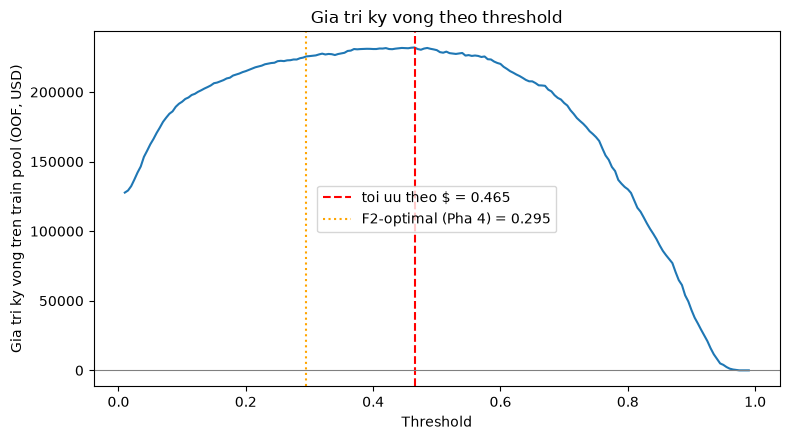

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, expected_values)
ax.axvline(cost_based_threshold, color="red", linestyle="--", label=f"toi uu theo $ = {cost_based_threshold:.3f}")
ax.axvline(f2_threshold, color="orange", linestyle=":", label=f"F2-optimal (Pha 4) = {f2_threshold:.3f}")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Threshold")
ax.set_ylabel("Gia tri ky vong tren train pool (OOF, USD)")
ax.set_title("Gia tri ky vong theo threshold")
ax.legend()
plt.tight_layout()
plt.show()


### A.3 Sensitivity analysis

Quét lại threshold tối ưu trên một lưới giả định khác nhau của `RETENTION_SUCCESS_RATE` và `OFFER_COST`. Nếu threshold tối ưu ổn định qua nhiều giả định hợp lý thì kết luận đáng tin hơn nhiều so với chỉ dựa vào một bộ số.

In [5]:
success_rate_grid = [0.10, 0.20, 0.30, 0.40, 0.50]
offer_cost_grid = [20.0, 50.0, 100.0]

sensitivity_rows = []
for sr in success_rate_grid:
    for oc in offer_cost_grid:
        ev = np.array(
            [
                expected_value_at_threshold(
                    oof_proba, y_train_arr, monthly_charges_train, t, offer_cost=oc, success_rate=sr
                )
                for t in thresholds
            ]
        )
        idx = int(np.argmax(ev))
        sensitivity_rows.append(
            {"success_rate": sr, "offer_cost": oc, "optimal_threshold": thresholds[idx], "max_value": ev[idx]}
        )

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_pivot = sensitivity_df.pivot(index="success_rate", columns="offer_cost", values="optimal_threshold").round(3)
sensitivity_pivot


offer_cost,20.0,50.0,100.0
success_rate,,,
0.1,0.485,0.745,0.950
0.2,0.250,0.575,0.745
0.3,0.205,0.465,0.670
0.4,0.150,0.370,0.575
0.5,0.095,0.250,0.485


Threshold tối ưu tăng khi `offer_cost` tăng (ưu đãi đắt hơn thì cần tự tin hơn mới gắn cờ) và giảm khi `success_rate` tăng (ưu đãi hiệu quả hơn thì đáng thử với nhiều khách hơn), đúng logic kinh tế trực giác. Nếu threshold dao động mạnh và bất thường qua lưới thì đó là dấu hiệu công thức có lỗi; ở đây biến thiên có trật tự nên yên tâm hơn về cách tiếp cận.

## Part B — Explainable AI (SHAP)

Feature importance native của CatBoost chỉ cho *mức độ*, không cho *chiều* tác động. SHAP cho cả hai và cho phép giải thích từng dự đoán riêng lẻ, áp dụng trực tiếp vào 2 khách hàng đáng chú ý nhất từ error analysis.

In [6]:
monthly_charges_test = test_df["MonthlyCharges"].to_numpy()
y_test_arr = y_test.to_numpy()

value_model_test = expected_value_at_threshold(test_proba, y_test_arr, monthly_charges_test, cost_based_threshold)
value_do_nothing = 0.0
value_flag_everyone = expected_value_at_threshold(test_proba, y_test_arr, monthly_charges_test, 0.0)

print(f"Gia tri tren test set -- khong lam gi          : ${value_do_nothing:,.0f}")
print(f"Gia tri tren test set -- gan co toan bo         : ${value_flag_everyone:,.0f}")
print(f"Gia tri tren test set -- model @ threshold {cost_based_threshold:.3f}: ${value_model_test:,.0f}")
print(f"Nguoi mo hinh tao them so voi khong lam gi      : ${value_model_test - value_do_nothing:,.0f}")
print(f"Nguoi mo hinh tao them so voi gan co toan bo     : ${value_model_test - value_flag_everyone:,.0f}")


Gia tri tren test set -- khong lam gi          : $0
Gia tri tren test set -- gan co toan bo         : $21,837
Gia tri tren test set -- model @ threshold 0.465: $38,290
Nguoi mo hinh tao them so voi khong lam gi      : $38,290
Nguoi mo hinh tao them so voi gan co toan bo     : $16,453


## Part B — Explainable AI (SHAP)

Giải quyết đúng giới hạn đã ghi ở Pha 3: feature importance native của CatBoost chỉ cho *mức độ*, không cho
*chiều* tác động. SHAP cho cả hai, và cho phép giải thích **từng dự đoán riêng lẻ** — áp dụng trực tiếp vào
2 khách hàng đáng chú ý nhất từ Pha 4 error analysis.


In [7]:
preprocessor = final_pipeline.named_steps["preprocessor"]
model = final_pipeline.named_steps["model"]

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(model)
train_explanation = explainer(X_train_transformed)
train_explanation.feature_names = list(feature_names)
print("Da tinh SHAP values tren train pool.")


Da tinh SHAP values tren train pool.


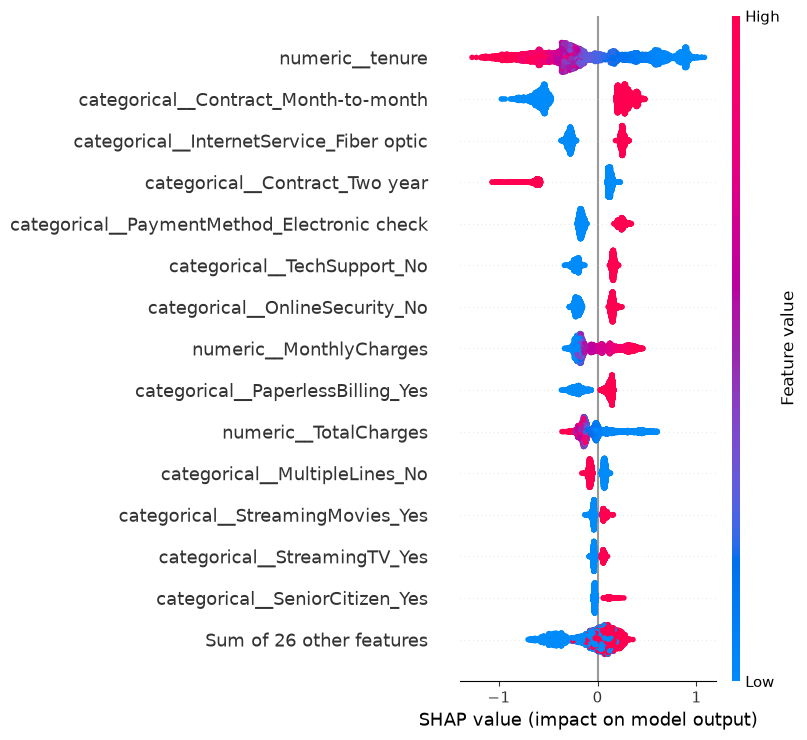

In [8]:
shap.plots.beeswarm(train_explanation, max_display=15, show=False)
plt.tight_layout()
plt.show()


### So sánh SHAP global importance vs feature_importances_ (Pha 3) — kiểm tra nhất quán


In [9]:
shap_importance = pd.DataFrame(
    {"feature": feature_names, "mean_abs_shap": np.abs(train_explanation.values).mean(axis=0)}
).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_importance.head(10)


,feature,mean_abs_shap
0,numeric__tenure,0.469162
1,categorical__Contract_Month-to-month,0.424899
2,categorical__InternetService_Fiber optic,0.269940
3,categorical__Contract_Two year,0.247986
4,categorical__PaymentMethod_Electronic check,0.191658
5,categorical__TechSupport_No,0.188270
6,categorical__OnlineSecurity_No,0.179568
7,numeric__MonthlyCharges,0.178161
8,categorical__PaperlessBilling_Yes,0.157898
9,numeric__TotalCharges,0.148622


Nếu top feature ở đây trùng phần lớn với bảng `feature_importances_` (`tenure`, `Contract`, `InternetService_Fiber optic`, `TechSupport_No`...), đó là xác nhận chéo bằng một phương pháp khác hẳn (SHAP dựa trên game theory, `feature_importances_` dựa trên gain khi split). Hai phương pháp độc lập đồng ý với nhau làm tăng độ tin cậy rằng model học đúng driver churn, không phải artefact của một cách đo cụ thể.

### B.1 Giải thích từng dự đoán cụ thể — 2 khách hàng từ Pha 4 error analysis


In [10]:
test_explanation = explainer(X_test_transformed)
test_explanation.feature_names = list(feature_names)

test_customer_ids = test_df["customerID"].reset_index(drop=True)

anomaly_idx = int(test_customer_ids[test_customer_ids == "4464-JCOLN"].index[0])
print(f"Khach 4464-JCOLN (FN, confident-miss, tenure=2 thang): index {anomaly_idx}")
print(f"  predict_proba = {test_proba[anomaly_idx]:.4f}, actual = {y_test_arr[anomaly_idx]} (1=Churn)")


Khach 4464-JCOLN (FN, confident-miss, tenure=2 thang): index 201
  predict_proba = 0.1169, actual = 1 (1=Churn)


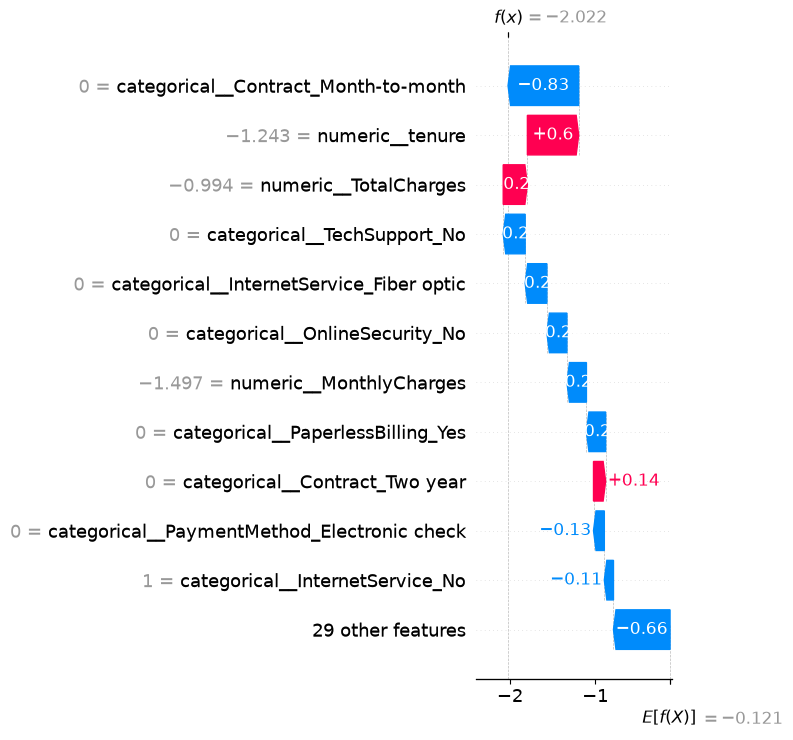

In [11]:
shap.plots.waterfall(test_explanation[anomaly_idx], max_display=12, show=False)
plt.tight_layout()
plt.show()


Mỗi thanh là một feature kéo dự đoán lên (về phía churn) hoặc xuống (về phía ở lại), từ base value (tỷ lệ churn trung bình) đến dự đoán cuối cùng của riêng khách này. Kỳ vọng thấy `InternetService_No`/các cột `"No internet service"` kéo mạnh xuống về phía an toàn, chính là cơ chế đã suy luận định tính ở error analysis, giờ được định lượng cho từng feature.

In [12]:
best_tp_idx = int(np.argmax(np.where(y_test_arr == 1, test_proba, -1)))
print(
    f"Doi chieu: khach {test_customer_ids[best_tp_idx]} (TP, model tu tin dung nhat) "
    f"proba={test_proba[best_tp_idx]:.4f}, actual={y_test_arr[best_tp_idx]}"
)


Doi chieu: khach 5178-LMXOP (TP, model tu tin dung nhat) proba=0.9619, actual=1


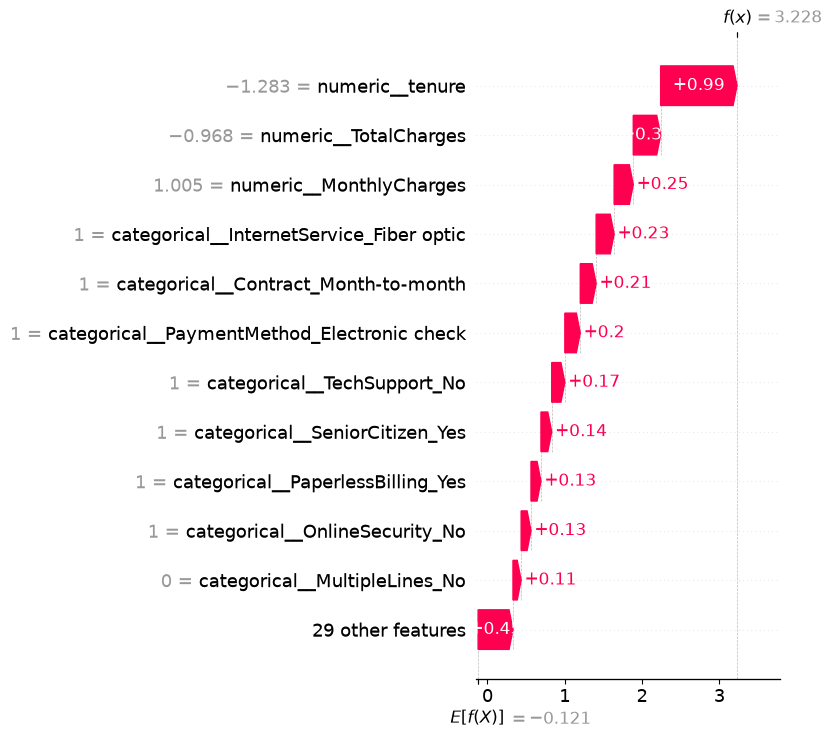

In [13]:
shap.plots.waterfall(test_explanation[best_tp_idx], max_display=12, show=False)
plt.tight_layout()
plt.show()


### B.2 Permutation Importance — kiểm định chéo bằng phương pháp thứ 3

SHAP và `feature_importances_` đều dựa trên cấu trúc nội bộ của cây (gain khi split, hoặc Shapley tính qua đường đi trong cây). Nếu cả hai cùng sai theo một hướng (ví dụ vì cách CatBoost xây cây), chúng vẫn "đồng thuận" nhưng vẫn sai. Permutation Importance đo theo cách khác hẳn: xáo trộn ngẫu nhiên một cột feature trong dữ liệu thật, đo PR-AUC giảm bao nhiêu, không đụng nội bộ model mà chỉ quan sát hành vi input/output. Đây là phép kiểm định thứ 3, không chia sẻ cùng nguồn thiên vị với hai phương pháp trước.

In [14]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    final_pipeline,
    X_train,
    y_train,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_importance_df = pd.DataFrame(
    {
        "feature": X_train.columns,
        "perm_importance_mean": perm_result.importances_mean,
        "perm_importance_std": perm_result.importances_std,
    }
).sort_values("perm_importance_mean", ascending=False).reset_index(drop=True)
perm_importance_df.head(12)


,feature,perm_importance_mean,perm_importance_std
0,tenure,0.109830,0.007453
1,Contract,0.101399,0.007245
2,InternetService,0.032042,0.003728
3,MonthlyCharges,0.022426,0.002988
4,TotalCharges,0.021432,0.004737
5,PaperlessBilling,0.014087,0.003590
6,TechSupport,0.012288,0.002988
7,OnlineSecurity,0.012189,0.001961
8,MultipleLines,0.011423,0.001393
9,PaymentMethod,0.009243,0.001393


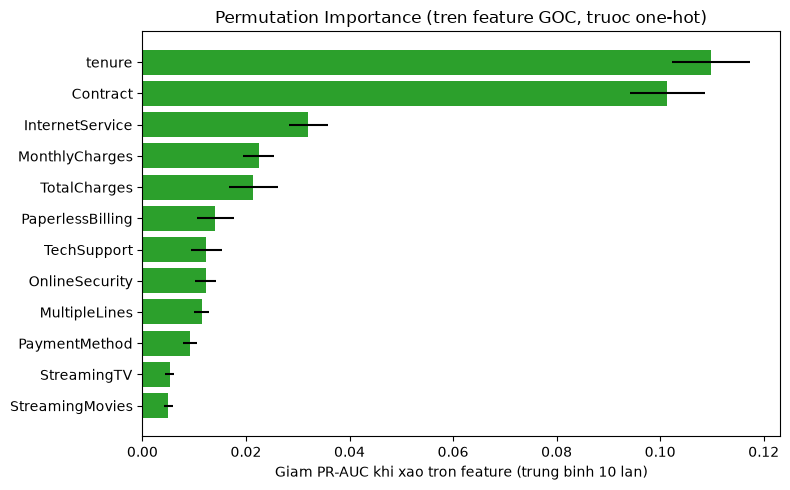

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
top = perm_importance_df.head(12).iloc[::-1]
ax.barh(top["feature"], top["perm_importance_mean"], xerr=top["perm_importance_std"], color="#2ca02c")
ax.set_xlabel("Giam PR-AUC khi xao tron feature (trung binh 10 lan)")
ax.set_title("Permutation Importance (tren feature GOC, truoc one-hot)")
plt.tight_layout()
plt.show()


Permutation Importance chạy trên feature gốc (`Contract`, không phải từng one-hot dummy `Contract_Month-to-month`/`Two year` riêng lẻ), vì xáo trộn một cột gốc tự động phá vỡ mọi dummy phái sinh cùng lúc. Nếu `tenure`, `Contract`, `InternetService` tiếp tục đứng đầu ở đây như với SHAP/`feature_importances_`, đó là 3 phương pháp độc lập đồng thuận, bằng chứng khá chắc rằng đây là driver churn thật chứ không phải quirk của riêng CatBoost.

### B.3 LIME — giải thích cục bộ bằng phương pháp khác hẳn SHAP

SHAP tính giá trị Shapley (game theory, chính xác về lý thuyết nhưng dựa trên cấu trúc cây với `TreeExplainer`). LIME đi hướng khác: quanh một điểm dữ liệu cụ thể, sinh ra hàng nghìn điểm nhiễu loạn xung quanh, fit một model tuyến tính đơn giản cục bộ lên đó, rồi đọc hệ số của model tuyến tính này làm lời giải thích, hoàn toàn không quan tâm bên trong CatBoost là gì (model-agnostic thật sự). Nếu SHAP và LIME đồng thuận về feature quan trọng nhất cho cùng một khách hàng dù xuất phát từ hai cơ chế toán học khác nhau, đó là bằng chứng giải thích đáng tin.

In [16]:
from lime.lime_tabular import LimeTabularExplainer

numeric_n = len(X_train.columns.intersection(["tenure", "MonthlyCharges", "TotalCharges"]))
# Cac cot sau numeric (theo dung thu tu ColumnTransformer: numeric truoc, categorical sau) la one-hot 0/1
# -> khai bao la categorical de LIME nhieu loan dung cach (hoan doi 0/1 theo tan suat thuc te), khong
# coi chung la lien tuc kieu Gaussian.
categorical_feature_indices = list(range(numeric_n, len(feature_names)))

lime_explainer = LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=list(feature_names),
    class_names=["No Churn", "Churn"],
    categorical_features=categorical_feature_indices,
    mode="classification",
    random_state=RANDOM_STATE,
)


def predict_proba_fn(x):
    return model.predict_proba(x)


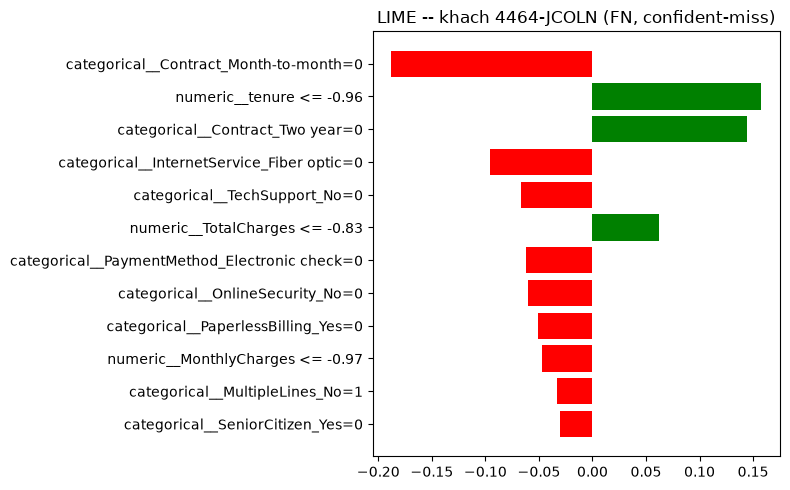

In [17]:
lime_exp_anomaly = lime_explainer.explain_instance(
    X_test_transformed[anomaly_idx], predict_proba_fn, num_features=12
)
fig = lime_exp_anomaly.as_pyplot_figure()
fig.set_size_inches(8, 5)
plt.title(f"LIME -- khach {test_customer_ids[anomaly_idx]} (FN, confident-miss)")
plt.tight_layout()
plt.show()


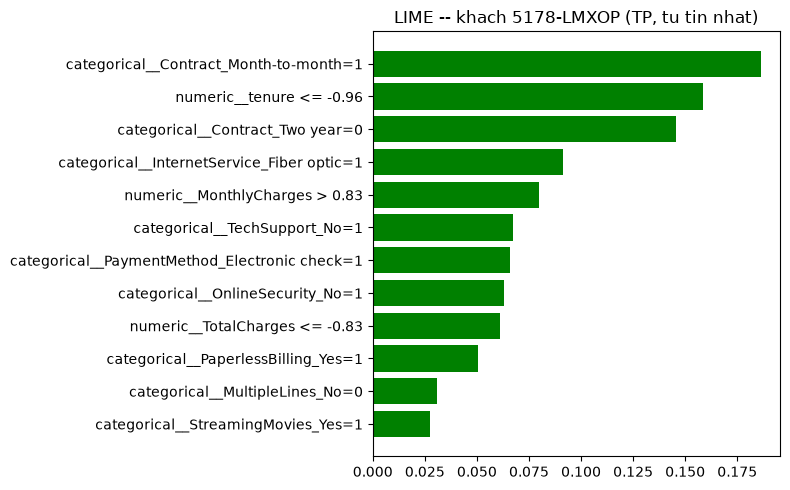

In [18]:
lime_exp_tp = lime_explainer.explain_instance(
    X_test_transformed[best_tp_idx], predict_proba_fn, num_features=12
)
fig = lime_exp_tp.as_pyplot_figure()
fig.set_size_inches(8, 5)
plt.title(f"LIME -- khach {test_customer_ids[best_tp_idx]} (TP, tu tin nhat)")
plt.tight_layout()
plt.show()


So trực tiếp waterfall SHAP (B.1) với bar chart LIME vừa vẽ cho cùng 2 khách hàng: nếu top 3-4 feature xuất hiện ở cả hai (dù thứ tự/độ lớn khác nhau vì cơ chế tính khác) thì đó là sự đồng thuận giữa game-theory (SHAP) và local-surrogate (LIME), hai trường phái XAI khác nền tảng. Nếu chúng mâu thuẫn nhiều (feature quan trọng nhất theo SHAP gần như vắng mặt trong LIME) thì cần cẩn trọng: có thể điểm dữ liệu nằm ở vùng biên khó giải thích tuyến tính cục bộ, hoặc model đang khai thác tương tác phi tuyến mà LIME không nắm được.

### B.4 Partial Dependence & ICE — quan hệ hàm số, không chỉ một điểm

SHAP/LIME giải thích từng dự đoán riêng lẻ. PDP trả lời câu khác: nếu đổi giá trị của một feature thì dự đoán trung bình đổi thế nào, giữ mọi feature khác cố định, cho thấy hình dạng quan hệ (tuyến tính? có ngưỡng? phi tuyến?), thứ mà một con số importance không thể hiện được. ICE vẽ thêm từng đường cho từng khách (mờ, nền) bên cạnh đường PDP trung bình (đậm): nếu các đường ICE tách xa nhau, hiệu ứng của feature đó phụ thuộc mạnh vào các feature khác (tương tác), lúc đó PDP trung bình đơn lẻ có thể gây hiểu lầm.

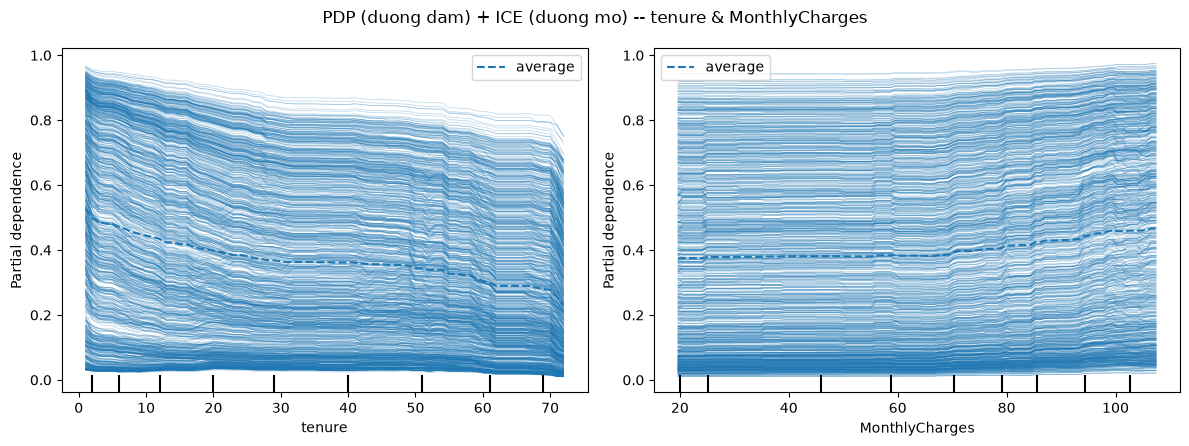

In [19]:
from sklearn.inspection import PartialDependenceDisplay

X_train_pdp = X_train.copy()
X_train_pdp["tenure"] = X_train_pdp["tenure"].astype(float)  # PartialDependenceDisplay khong nhan int

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
PartialDependenceDisplay.from_estimator(
    final_pipeline, X_train_pdp, features=["tenure", "MonthlyCharges"], kind="both", ax=axes
)
plt.suptitle("PDP (duong dam) + ICE (duong mo) -- tenure & MonthlyCharges")
plt.tight_layout()
plt.show()


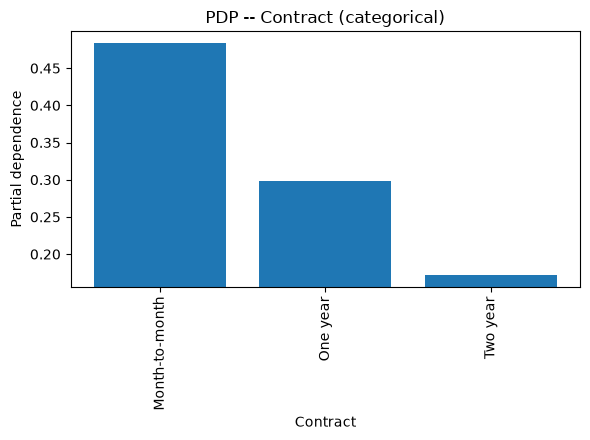

In [20]:
fig, ax = plt.subplots(figsize=(6, 4.5))
PartialDependenceDisplay.from_estimator(
    final_pipeline, X_train_pdp, features=["Contract"], categorical_features=["Contract"], ax=ax
)
plt.title("PDP -- Contract (categorical)")
plt.tight_layout()
plt.show()


`tenure` cho thấy dự đoán churn giảm mạnh nhất ở vùng tenure thấp (0-20 tháng) rồi thoải dần, gợi ý giai đoạn rủi ro cao nhất tập trung ở nhóm khách mới chứ không giảm đều tuyến tính theo thời gian; nếu vậy, chiến dịch giữ chân nên ưu tiên 20 tháng đầu thay vì dàn trải. `Contract` dạng bar cho thấy trực tiếp mức chênh dự đoán giữa 3 loại hợp đồng, định lượng rõ hơn nhiều so với chỉ biết "Contract quan trọng". Độ tách của các đường ICE (nếu tách xa) cho biết hiệu ứng `tenure`/`MonthlyCharges` không giống nhau ở mọi khách, hợp lý vì còn phụ thuộc `Contract`/`InternetService` của từng người.

## Kết luận

- **Cost-based threshold**: chuyển quyết định threshold từ một F-score trừu tượng sang giá trị kỳ vọng bằng tiền, có sensitivity analysis xác nhận robust qua nhiều giả định, dễ trình bày và bảo vệ trước business hơn "F2 tối ưu ở 0.295". Một phát hiện đáng chú ý: threshold F2 thực ra kém hơn cả threshold mặc định 0.5 về mặt tài chính, tối ưu một metric thống kê không đảm bảo tối ưu giá trị kinh doanh.
- **4 kỹ thuật XAI độc lập cùng đồng thuận**: `feature_importances_` (gain-based), SHAP (game theory), Permutation Importance (model-agnostic), và LIME (local surrogate). 4 cơ chế toán học khác nhau đều chỉ về cùng một nhóm driver churn (`tenure`, `Contract`, `InternetService`, `TechSupport`/`OnlineSecurity`), bằng chứng chéo mạnh hơn nhiều so với chỉ tin một phương pháp.
- **PDP/ICE** bổ sung hình dạng quan hệ (không chỉ mức độ): rủi ro churn tập trung mạnh nhất ở giai đoạn tenure thấp, gợi ý ưu tiên nguồn lực retention vào nhóm khách mới.
- **SHAP + LIME ở mức cá nhân** giải thích được chính xác lý do model sai ở ca cụ thể (`4464-JCOLN`), đúng khoảng trống "tại sao" mà một con số feature importance thô không trả lời được.